# Week 4 Project
- Task 7

> Marks Predictor & Pass/Fail Classifier — one regression model predicting marks from study hours, and one classifier predicting pass/fail, each with a short evaluation summary.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression


In [ ]:

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

In [ ]:
# 1. DATASET

study_hours = np.array([
    1, 2, 2.5, 3, 3.5,
    4, 4.5, 5, 5.5, 6,
    6.5, 7, 7.5, 8, 9
])

marks = np.array([
    35, 40, 45, 50, 52,
    58, 60, 65, 68, 72,
    75, 78, 82, 85, 92
])
 
pass_fail = (marks >= 50).astype(int)


# Convert X into 2D format
X = study_hours.reshape(-1, 1)

In [ ]:
# 2. REGRESSION MODEL

print("MARKS PREDICTOR")
print("=" * 30)


# Create model
regression_model = LinearRegression()


# Train model
regression_model.fit(X, marks)


# Predict training data
marks_pred = regression_model.predict(X)


# Evaluate
mae = mean_absolute_error(marks, marks_pred)

mse = mean_squared_error(marks, marks_pred)

r2 = r2_score(marks, marks_pred)


print("\nRegression Equation:")

print(
    f"Marks = "
    f"{regression_model.coef_[0]:.2f} × Study Hours "
    f"+ {regression_model.intercept_:.2f}"
)


print("\nRegression Evaluation:")

print(f"MAE: {mae:.2f}")

print(f"MSE: {mse:.2f}")

print(f"R²: {r2:.4f}")



MARKS PREDICTOR

Regression Equation:
Marks = 7.28 × Study Hours + 27.41

Regression Evaluation:
MAE: 0.74
MSE: 0.80
R²: 0.9971


In [ ]:
# 3. NEW STUDENT MARKS PREDICTION

new_student_hours = np.array([[6.5]])

predicted_marks = regression_model.predict(
    new_student_hours
)[0]


print("\nNew Student:")

print("Study Hours:", new_student_hours[0][0])

print(
    f"Predicted Marks: {predicted_marks:.2f}"
)




New Student:
Study Hours: 6.5
Predicted Marks: 74.72


In [ ]:
# 4. CLASSIFICATION MODEL

print("PASS / FAIL CLASSIFIER")
 
# Create classifier
classifier = LogisticRegression()


# Train classifier
classifier.fit(X, pass_fail)


# Predict classes
pass_fail_pred = classifier.predict(X)


# Predict probabilities
pass_probability = classifier.predict_proba(X)[:, 1]



PASS / FAIL CLASSIFIER


In [ ]:
# 5. CLASSIFICATION EVALUATION

accuracy = accuracy_score(
    pass_fail,
    pass_fail_pred
)

precision = precision_score(
    pass_fail,
    pass_fail_pred
)

recall = recall_score(
    pass_fail,
    pass_fail_pred
)


print("\nClassification Evaluation:")

print(f"Accuracy: {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall: {recall:.4f}")


print("\nConfusion Matrix:")

print(
    confusion_matrix(
        pass_fail,
        pass_fail_pred
    )
)




Classification Evaluation:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000

Confusion Matrix:
[[ 3  0]
 [ 0 12]]


In [ ]:
# 6. NEW STUDENT PASS/FAIL PREDICTION

new_student_hours = np.array([[6.5]])


prediction = classifier.predict(
    new_student_hours
)[0]


probability = classifier.predict_proba(
    new_student_hours
)[0][1]


print("\nNew Student:")

print("Study Hours:", new_student_hours[0][0])

print(
    f"Probability of Passing: "
    f"{probability:.2%}"
)


if prediction == 1:

    print("Prediction: PASS")

else:

    print("Prediction: FAIL")




New Student:
Study Hours: 6.5
Probability of Passing: 99.44%
Prediction: PASS


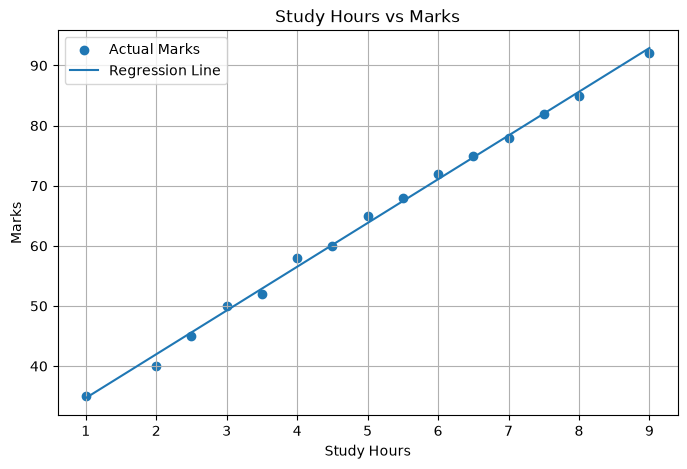

In [ ]:
# 7. REGRESSION VISUALIZATION

plt.figure(figsize=(8, 5))


plt.scatter(
    study_hours,
    marks,
    label="Actual Marks"
)


plt.plot(
    study_hours,
    marks_pred,
    label="Regression Line"
)


plt.xlabel("Study Hours")

plt.ylabel("Marks")

plt.title(
    "Study Hours vs Marks"
)

plt.legend()

plt.grid()

plt.show()



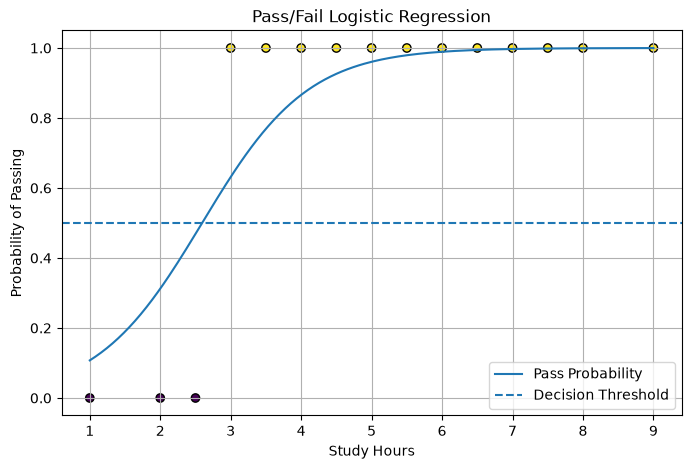

In [ ]:
# 8. CLASSIFICATION VISUALIZATION

plt.figure(figsize=(8, 5))


plt.scatter(
    study_hours,
    pass_fail,
    c=pass_fail,
    edgecolors="black"
)


# Probability curve
hours_range = np.linspace(
    study_hours.min(),
    study_hours.max(),
    200
).reshape(-1, 1)


probabilities = classifier.predict_proba(
    hours_range
)[:, 1]


plt.plot(
    hours_range,
    probabilities,
    label="Pass Probability"
)


plt.axhline(
    0.5,
    linestyle="--",
    label="Decision Threshold"
)


plt.xlabel("Study Hours")

plt.ylabel("Probability of Passing")

plt.title(
    "Pass/Fail Logistic Regression"
)

plt.legend()

plt.grid()

plt.show()